## Question 1

A blob is a region in an image that:
Has similar intensity or color,
    Differs significantly from the surrounding background,
    And usually represents a localized feature or object.

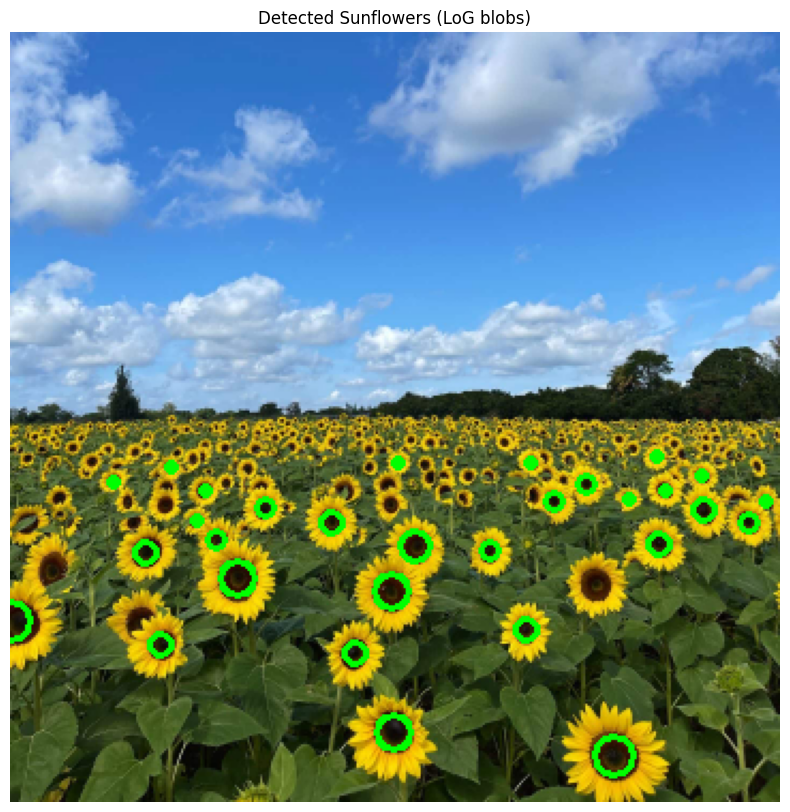

Largest Circle Parameters:
 Center: (0, 275)
 Radius: 9.90 pixels
 Corresponding σ: 7.00
 σ range used: 1.00 – 10.00


In [24]:
import cv2 as cv
import numpy as np
from scipy import ndimage as ndi
import matplotlib.pyplot as plt

im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
gray = gray / 255.0  # normalize to [0, 1]

#Scale-space parameters
sigma_values = np.linspace(1, 10, 10) 
h, w = gray.shape
response_stack = np.zeros((h, w, len(sigma_values)))
# Laplacian of Gaussian (LoG) response for each σ
for i, sigma in enumerate(sigma_values):
    blurred = cv.GaussianBlur(gray, (0, 0), sigma)
    log_resp = cv.Laplacian(blurred, cv.CV_64F)
    response_stack[:, :, i] = np.abs(log_resp) * (sigma ** 2)
# Local maxima across space and scale
maxima = (response_stack == ndi.maximum_filter(response_stack, size=(3, 3, 3)))

# Get coordinates of blob centers
y, x, s = np.where(maxima)
radii = np.sqrt(2) * sigma_values[s]

# Pick top N strongest blobs
strength = response_stack[y, x, s]
indices = np.argsort(strength)[-30:]  # top 30
y, x, s, radii = y[indices], x[indices], s[indices], radii[indices]

output = im.copy()
for (xi, yi, ri) in zip(x, y, radii):
    cv.circle(output, (int(xi), int(yi)), int(ri), (0, 255, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title("Detected Sunflowers (LoG blobs)")
plt.axis("off")
plt.show()

largest_idx = np.argmax(radii)
print("Largest Circle Parameters:")
print(f" Center: ({x[largest_idx]}, {y[largest_idx]})")
print(f" Radius: {radii[largest_idx]:.2f} pixels")
print(f" Corresponding σ: {sigma_values[s[largest_idx]]:.2f}")
print(f" σ range used: {sigma_values[0]:.2f} – {sigma_values[-1]:.2f}")


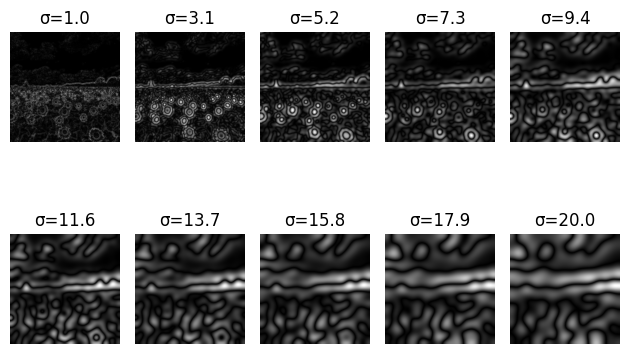

In [13]:
import matplotlib.pyplot as plt

for i, sigma in enumerate(sigma_values):
    plt.subplot(2, 5, i+1)
    plt.imshow(response_stack[:, :, i], cmap='gray')
    plt.title(f"σ={sigma:.1f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


## Question 2